# Импорт библиотек

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Загрузка и первичная очистка данных


In [26]:
# Загрузка данных
df = pd.read_csv('agriculture.csv', sep=';', encoding='cp1251')

# Очистка названий столбцов
df.columns = df.columns.str.strip()

# Приведение строковых значений к единому виду
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

# Удаление суффикса у названия продукции
df['Наименование вида сельхоз. продукции'] = (
    df['Наименование вида сельхоз. продукции']
    .str.replace(', тыс. штук', '', regex=False)
)

# Функция преобразования строк в числа
def convert_to_float(series):
    series = series.astype(str).str.replace(',', '.', regex=False).str.strip()
    return pd.to_numeric(series, errors='coerce')

# Преобразование числовых столбцов
df['Показатель, тыс. ед.'] = convert_to_float(df['Показатель, тыс. ед.'])
df['Доля'] = convert_to_float(df['Доля'])
df['Темп роста, %'] = convert_to_float(df['Темп роста, %'])
df['Год'] = pd.to_numeric(df['Год'], errors='coerce')

# Проверим данные
print(df.head())
print(df.info())
print(df.isna().sum())

            Сектор Наименование вида сельхоз. продукции   Год  \
0  растениеводство                   капуста всех видов  1999   
1  растениеводство                   капуста всех видов  2000   
2  растениеводство                   капуста всех видов  2001   
3  растениеводство                   капуста всех видов  2002   
4  растениеводство                   капуста всех видов  2003   

   Показатель, тыс. ед.      Доля  Темп роста, % Категория  
0                166.18  0.002884            NaN   высокий  
1                156.63  0.002820      -5.746781   высокий  
2                146.04  0.002609      -6.761157   высокий  
3                140.55  0.002487      -3.759244   высокий  
4                137.69  0.002613      -2.034863   высокий  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1118 entries, 0 to 1117
Data columns (total 7 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0 

# Формирование целевой переменной


In [27]:
# Кодирование целевой переменной
target_map = {'низкий': 0, 'средний': 1, 'высокий': 2}
df['Категория_ord'] = df['Категория'].map(target_map)

# Признаки и целевая переменная
X = df.drop(columns=['Категория', 'Категория_ord'])
y = df['Категория_ord']

print("Размер X:", X.shape)
print("Размер y:", y.shape)
print("Распределение классов:")
print(y.value_counts())

Размер X: (1118, 6)
Размер y: (1118,)
Распределение классов:
Категория_ord
2    387
0    387
1    344
Name: count, dtype: int64


# Разделение на обучающую и тестовую выборки

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)

Обучающая выборка: (894, 6)
Тестовая выборка: (224, 6)


# Подготовка признаков


In [29]:
numeric_features = ['Год', 'Показатель, тыс. ед.', 'Доля', 'Темп роста, %']
categorical_features = ['Сектор', 'Наименование вида сельхоз. продукции']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Создание моделей

In [30]:
logreg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])

svm_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SVC(kernel='rbf', random_state=42))
])

tree_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42, max_depth=5))
])

# Обучение моделей

In [31]:
logreg_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Год',
                                                   'Показатель, тыс. ед.',
                                                   'Доля', 'Темп роста, %']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Сектор',
                                                   'Наименование вида сельхоз. '
                                                   'продукции'])])),
                ('model',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])

# Оценка качества моделей

In [32]:
# Предсказания
y_pred_logreg = logreg_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)
y_pred_tree = tree_model.predict(X_test)

# Метрики
results = pd.DataFrame({
    'Модель': ['Логистическая регрессия', 'SVM', 'Дерево решений'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_tree)
    ],
    'F1-macro': [
        f1_score(y_test, y_pred_logreg, average='macro'),
        f1_score(y_test, y_pred_svm, average='macro'),
        f1_score(y_test, y_pred_tree, average='macro')
    ]
})

print(results)

                    Модель  Accuracy  F1-macro
0  Логистическая регрессия  0.294643  0.267867
1                      SVM  0.611607  0.616388
2           Дерево решений  0.607143  0.606191


# Отчеты по моделям

In [33]:
print("Логистическая регрессия")
print(classification_report(y_test, y_pred_logreg))

print("SVM")
print(classification_report(y_test, y_pred_svm))

print("Дерево решений")
print(classification_report(y_test, y_pred_tree))

Логистическая регрессия
              precision    recall  f1-score   support

           0       0.29      0.38      0.33        78
           1       0.16      0.07      0.10        69
           2       0.34      0.40      0.37        77

    accuracy                           0.29       224
   macro avg       0.26      0.29      0.27       224
weighted avg       0.27      0.29      0.27       224

SVM
              precision    recall  f1-score   support

           0       0.69      0.58      0.63        78
           1       0.47      0.70      0.56        69
           2       0.79      0.57      0.66        77

    accuracy                           0.61       224
   macro avg       0.65      0.61      0.62       224
weighted avg       0.65      0.61      0.62       224

Дерево решений
              precision    recall  f1-score   support

           0       0.67      0.64      0.65        78
           1       0.53      0.67      0.59        69
           2       0.63      0.5

# Матрица ошибок для дерева решений

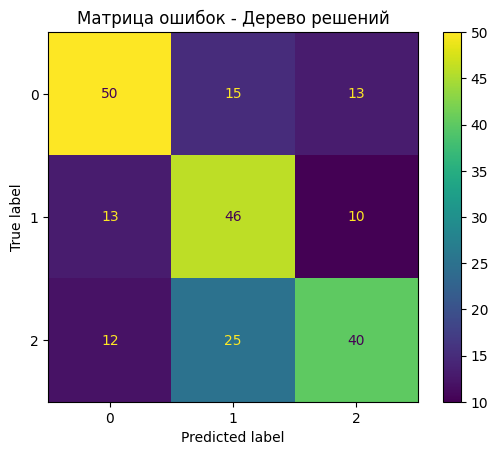

In [34]:
cm = confusion_matrix(y_test, y_pred_tree)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Матрица ошибок - Дерево решений')
plt.show()

# Важность признаков для дерева решений

In [39]:
# Получаем обученный препроцессор и дерево
fitted_preprocessor = tree_model.named_steps['preprocessor']
fitted_tree = tree_model.named_steps['model']

# Имена признаков после преобразования
feature_names = fitted_preprocessor.get_feature_names_out()

# Сокращённые названия признаков
feature_names_short = []
for name in feature_names:
    name = name.replace('num__', '')
    name = name.replace('cat__', '')
    name = name.replace('Наименование вида сельхоз. продукции_', 'вид=')
    name = name.replace('Сектор_', 'сектор=')
    feature_names_short.append(name[:25])   # можно обрезать до 25 символов

print(feature_names_short[:10])

['Год', 'Показатель, тыс. ед.', 'Доля', 'Темп роста, %', 'сектор=животноводство', 'сектор=растениеводство', 'сектор=рыбоводство', 'вид=горчица', 'вид=гречиха', 'вид=зернобобовые культуры']


# Дерево решений

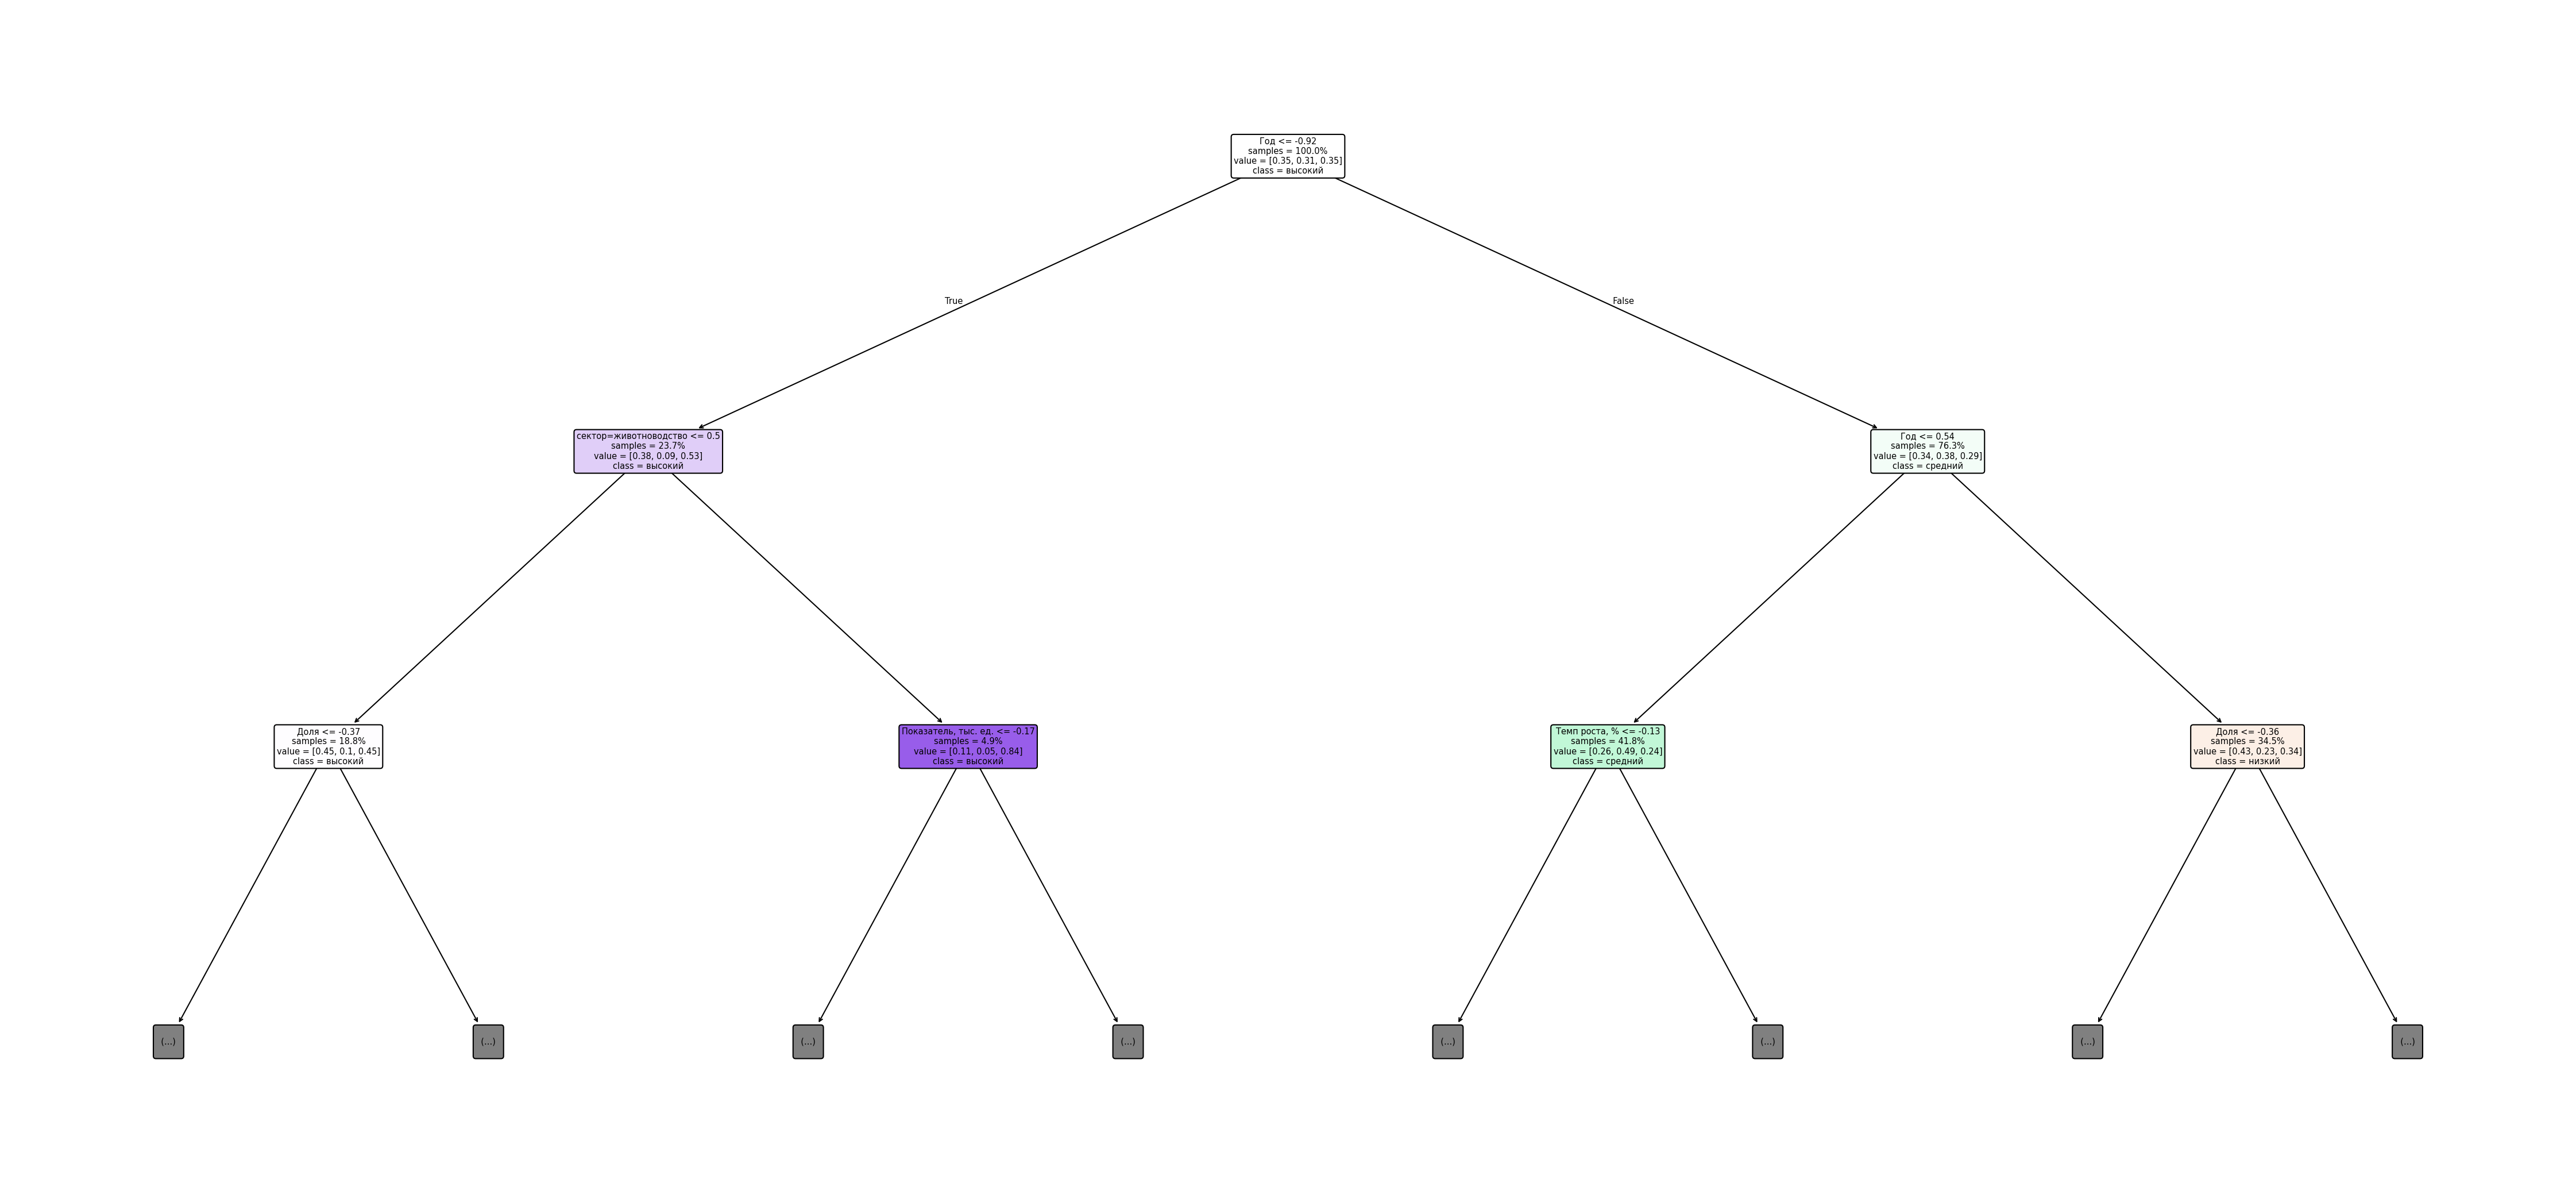

In [38]:
plt.figure(figsize=(30, 14), dpi=150)
plot_tree(
    fitted_tree,
    feature_names=feature_names_short,
    class_names=['низкий', 'средний', 'высокий'],
    filled=True,
    rounded=True,
    max_depth=2,
    fontsize=7,
    impurity=False,
    proportion=True,
    precision=2
)
plt.tight_layout()
plt.show()

# Выводы
В лабораторной работе были обучены и сравнены три модели классификации: логистическая регрессия, SVM и дерево решений. Перед обучением выполнена предварительная обработка данных: заполнение пропусков, кодирование категориальных признаков и масштабирование числовых признаков. Качество моделей оценивалось по метрикам accuracy и F1-macro. Также была определена важность признаков для дерева решений и выполнена его визуализация. По результатам сравнения выбрана модель, показавшая наилучшее качество на тестовой выборке.